In [ ]:
!pip install mglearn
import mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 20.0 MB/s eta 0:00:00


w[0]: 0.393906  b: -0.031804


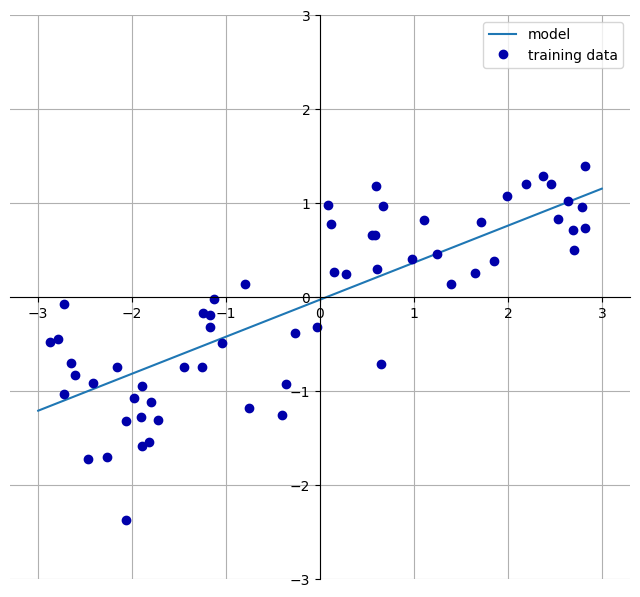

In [ ]:
mglearn.plots.plot_linear_regression_wave()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
X,y=mglearn.datasets.make_wave(n_samples=60)
line=LinearRegression().fit(X,y)
print(line.coef_)

[0.42073384]


In [ ]:
print(line.intercept_)

-0.059832458303618025


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)
lr=LinearRegression().fit(X_train,y_train)
print(lr.coef_)

[0.39390555]


In [ ]:
print(lr.intercept_)

-0.031804343026759746


In [ ]:
print(lr.score(X_train,y_train))

0.6700890315075756


In [ ]:
print(lr.score(X_test,y_test))

0.65933685968637


In [ ]:
print(line.score(X,y))

0.6706090630745324


In [61]:
import pandas as pd
import numpy as np

# Dataset URL
data_url = "http://lib.stat.cmu.edu/datasets/boston"

# Read raw data with raw string for regex separator
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# Create X and y
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = LinearRegression().fit(X_train, y_train)

print("coef:", model.coef_)
print("intercept:", model.intercept_)
print("train score:", model.score(X_train, y_train))
print("test score:", model.score(X_test, y_test))

coef: [-1.28322638e-01  2.95517751e-02  4.88590934e-02  2.77350326e+00
 -1.62388292e+01  4.36875476e+00 -9.24808158e-03 -1.40086668e+00
  2.57761243e-01 -9.95694820e-03 -9.23122944e-01  1.31854199e-02
 -5.17639519e-01]
intercept: 29.836420163838568
train score: 0.748087259862344
test score: 0.6844267283527075


In [63]:
X.shape

(506, 13)

In [64]:
y.shape

(506,)

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# Fetch the dataset from UCI
student = fetch_ucirepo(id=320)

# X and y
X = student.data.features
y = student.data.targets

print(X.head())
print(y.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  higher internet  romantic  famrel  freetime goout Dalc Walc health absences  
0    yes       no        no       4         3     4    1    1      3        4  
1    yes      yes        no       5         3     3    1    1      3        2  
2    yes      yes        no       4         3     2    2    3      3        6  
3    yes      yes       yes       3         2     2    1    1      5        0  
4    yes       no        no       4         3     2    1    2      5        0  

[5 rows x 30 columns]
   G1  G2 

In [ ]:
cols = ['studytime','failures','absences','age']
X_selected = X[cols]

In [ ]:
df = X.copy()
df['G1'] = y['G1']
df['G2'] = y['G2']
df['G3'] = y['G3']

In [ ]:
cols = ['G1','G2','G3','studytime','failures','absences','age']
X_selected = df[cols]
X_selected.head()

,G1,G2,G3,studytime,failures,absences,age
0,0,11,11,2,0,4,18
1,9,11,11,2,0,2,17
2,12,13,12,2,0,6,15
3,14,14,14,3,0,0,15
4,11,13,13,2,0,0,16


In [ ]:
X_selected.rename(columns={'G1':'Midterm-1','G2':'Midterm-2','G3':'Final'},inplace=True)
X_selected.head()

/tmp/ipykernel_410/3581921949.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_selected.rename(columns={'G1':'Midterm-1','G2':'Midterm-2','G3':'Final'},inplace=True)


,Midterm-1,Midterm-2,Final,studytime,failures,absences,age
0,0,11,11,2,0,4,18
1,9,11,11,2,0,2,17
2,12,13,12,2,0,6,15
3,14,14,14,3,0,0,15
4,11,13,13,2,0,0,16


In [ ]:
X_selected.dtypes

,0
Midterm-1,int64
Midterm-2,int64
Final,int64
studytime,int64
failures,int64
absences,int64
age,int64


In [ ]:
import numpy as np
y=np.array(X_selected['Final'])
X=np.array(X_selected.drop('Final',axis=1))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)
linear=LinearRegression().fit(X_train,y_train)

In [ ]:
linear.score(X_test,y_test)

0.7640720201641849

In [ ]:
linear.score(X_train,y_train)

0.8756088745383117

In [ ]:
print('coefficient: \n',linear.coef_)
print('intercept:  \n',linear.intercept_)

coefficient: 
 [ 0.11732409  0.89622567  0.07941146 -0.16965934  0.01249468  0.03251473]
intercept:  
 -0.4834980973248193


In [ ]:
new_data=np.array([[10,14,3,0,4,16]])
linear.predict(new_data)

array([14.04535105])

In [ ]:
data2=np.array([[15,14,3,0,2,15]])
linear.predict(data2)

array([14.57446743])